<font size=3;>
<p style="text-align: right;"> Lab Solution --- <b>NOT FOR DISTRIBUTION!</b> </p>
</font>

# Lab N: Interaction

## Setup

In [1]:
# Import some useful functions
from numpy import *
from numpy.random import *
from datascience import *
from statsmodels.formula.api import *

# Define some useful functions
def correlation(array_1, array_2):
    return corrcoef(array_1, array_2).item(1)

# Customize look of graphics
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
plt.rcParams['figure.dpi'] = 60
%matplotlib inline

# Force display of all values 
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# Hide some unnecessary warning messages
import warnings
warnings.filterwarnings("ignore")
import numpy
numpy.int = numpy.int_

## Advertising & Pricing Beauty Products

### Business Decision

Tyler Beauty Products advertises and sells beauty products.  It recently conducted a set of marketing programs at various retail stores, where products were priced at 3 different levels: \\$2.00, \\$2.50, or \\$3.00.  Each of these stores advertised at 2 different budget levels: \\$50,000 or \\$100,000.  The product manager must now decide on advertising budgets of \\$50,000 or \\$100,000 at each of several new stores.  For various strategic reasons, each of the new stores has already decided whether to price the beauty products at \\$2.00, \\$2.50, or \\$3.00.

### Retrieve Data

Retrieve data from file 'Tyler.csv'. Show ALL marketing program results.

In [2]:
data = Table().read_table('Tyler.csv')
data.show()

Store,Price,Budget,Sales
A,2,50,478
A,2.5,50,373
A,3,50,367
B,2,50,473
B,2.5,50,358
B,3,50,356
C,2,50,456
C,2.5,50,360
C,3,50,367
D,2,50,437


### Analysis

#### Model 1

Build a multiple linear regression model to predict 'Sales' based on 'Price' and 'Budget'.  Show the model goodness of fit (R^2).  Show the model parameter values (intercept and coefficients).

In [3]:
model = ols('Sales ~ Price + Budget', data).fit()
model.rsquared
model.params

0.79054033560558379

Intercept    871.833333
Price       -273.000000
Budget         4.146667
dtype: float64

Build a report that shows what sales and profits the model would predict for each combination of price and budget.
Calculate profit as sales minus budget.

In [4]:
report = Table().with_columns('Price', make_array(2, 2.5, 3))

report = report.with_column('Budget', make_array(50, 50, 50))
report = report.with_column('sales_predicted_50', model.predict(report))
report = report.with_column('profit_50', report.column('sales_predicted_50')-report.column('Budget'))

report = report.with_column('Budget', make_array(100, 100, 100)) # replace Budget amount
report = report.with_column('sales_predicted_100', model.predict(report))
report = report.with_column('profit_100', report.column('sales_predicted_100')-report.column('Budget'))

report = report.drop('Budget')

report

Price,sales_predicted_50,profit_50,sales_predicted_100,profit_100
2,533.167,483.167,740.5,640.5
2.5,396.667,346.667,604,504
3,260.167,210.167,467.5,367.5


Visualize predicted profits at budget \\$50,000 and budget \\$100,000 vs. price, as a line plot.

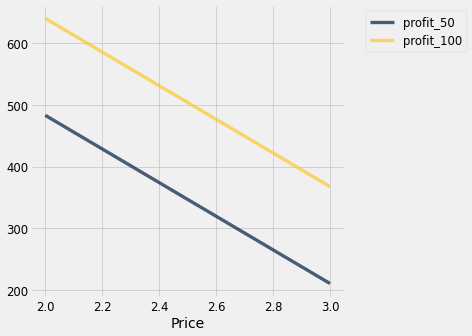

In [5]:
report.select('Price','profit_50','profit_100').plot('Price')

For each price, determine which budget results in the best predicted profit.

In [6]:
for price in make_array(2, 2.5, 3):
    budget = make_array('Budget 50', 'Budget 100')
    profit_50  = report.where('Price', price).column('profit_50').item(0)
    profit_100 = report.where('Price', price).column('profit_100').item(0)
    (price, budget.item((profit_50<profit_100)*1), max(profit_50, profit_100))

(2.0, 'Budget 100', 640.499999999986)

(2.5, 'Budget 100', 503.999999999986)

(3.0, 'Budget 100', 367.499999999986)

#### Model 2

Add a synthetic numeric variable called 'priceXbudget' to the data, with values that are the product of 'Price' and
'Budget'. This is an INTERACTION variable. Show ALL the marketing program results.

In [7]:
data = data.with_column('priceXbudget', data.column('Price') * data.column('Budget'))
data.show()

Store,Price,Budget,Sales,priceXbudget
A,2,50,478,100
A,2.5,50,373,125
A,3,50,367,150
B,2,50,473,100
B,2.5,50,358,125
B,3,50,356,150
C,2,50,456,100
C,2.5,50,360,125
C,3,50,367,150
D,2,50,437,100


Build a multiple linear regression model to predict 'Sales' based on 'Price', 'Budget', and 'priceXbudget'.  Show the model goodness of fit (R^2).  Show the model parameter values (intercept and coefficients).

In [8]:
model = ols('Sales ~ Price + Budget + priceXbudget', data).fit()
model.rsquared
model.params

0.96870663704400173

Intercept      -455.666667
Price           258.000000
Budget           21.846667
priceXbudget     -7.080000
dtype: float64

Build a report that shows what sales and profits the model would predict for each combination of price and budget.
Calculate profit as sales minus budget.

In [9]:
report = Table().with_columns('Price', make_array(2, 2.5, 3))

report = report.with_column('Budget', make_array(50, 50, 50))
report = report.with_column('priceXbudget', make_array(50*2, 50*2.5, 50*3))
report = report.with_column('sales_predicted_50', model.predict(report))
report = report.with_column('profit_50', report.column('sales_predicted_50')-report.column('Budget'))

report = report.with_column('Budget', make_array(100, 100, 100))
report = report.with_column('priceXbudget', make_array(100*2, 100*2.5, 100*3))
report = report.with_column('sales_predicted_100', model.predict(report))
report = report.with_column('profit_100', report.column('sales_predicted_100')-report.column('Budget'))

report = report.drop('Budget')
report = report.drop('priceXbudget')

report

Price,sales_predicted_50,profit_50,sales_predicted_100,profit_100
2,444.667,394.667,829,729
2.5,396.667,346.667,604,504
3,348.667,298.667,379,279


Visualize predicted profits at budget \\$50,000 and budget \\$100,000 vs. price, as a line plot.

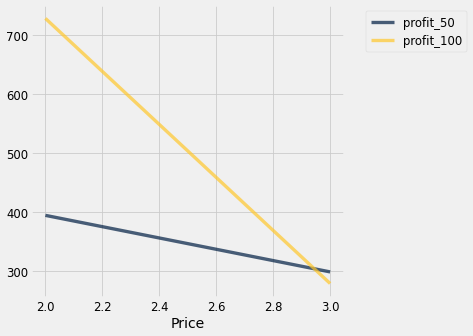

In [10]:
report.select('Price','profit_50','profit_100').plot('Price')

For each price, determine which budget results in the best predicted profit.

In [11]:
for price in make_array(2, 2.5, 3):
    budget = make_array('Budget 50', 'Budget 100')
    profit_50  = report.where('Price', price).column('profit_50').item(0)
    profit_100 = report.where('Price', price).column('profit_100').item(0)
    (price, budget.item((profit_50<profit_100)*1), max(profit_50, profit_100))

(2.0, 'Budget 100', 728.999999999985)

(2.5, 'Budget 100', 503.9999999999811)

(3.0, 'Budget 50', 298.6666666666549)

Calculate the price where it becomes more profitable to budget \\$50,000 than to budget \\$100,000.

$$
\textit{predicted profit at budget 50,000} = \big( i + (c_1)(\textit{price}) + (c_2)(50) + (c_3)(\textit{price})(50) \big) - 50
$$

$$
\textit{predicted profit at budget 100,000} = \big( i + (c_1)(\textit{price}) + (c_2)(100) + (c_3)(\textit{price})(100) \big) - 100
$$

$$
i + (c_1)(\textit{price}) + (c_2)(50) + (c_3)(\textit{price})(50) - 50 = i + (c_1)(\textit{price}) + (c_2)(100) + (c_3)(\textit{price})(100) - 100
$$

$$
(c_2)(50) + (c_3)(\textit{price})(50) - 50 = (c_2)(100) + (c_3)(\textit{price})(100) - 100
$$

$$
(c_2)(50) - (c_2)(100) - 50 + 100 =  (c_3)(\textit{price})(100) - (c_3)(\textit{price})(50)
$$

$$
(c_2)(50) - (c_2)(100) - 50 + 100 = (\textit{price}) \big((c_3)(100) - (c_3)(50)\big)
$$

$$
\cfrac{(c_2)(50) - (c_2)(100) - 50 + 100}{(c_3)(100) - (c_3)(50)}  = \textit{price}
$$


In [13]:
c2 = model.params[2]
c3 = model.params[3]

crossover = (c2*50 - c2*100 - 50 + 100) / (c3*100 - c3*50)
crossover

2.9444444444444144

<p style="text-align:left; font-size:10px;">
Copyright (c) Huntsinger Associates, LLC
<span style="float:right;">
Document revised November 24, 2023
</span>
</p>